# Dataset characterization for residue-level RCI-S2 targets

This notebook characterizes the residue-level dataset **before** model training. It is designed for the thesis workflow using:

- `residue_table_trimmed.csv`
- `protein_manifest_trimmed.csv`
- optional ML-ready datasets for ESM-2 / ProtT5

## Goals

1. Inspect the **target distribution** of RCI-S2.
2. Quantify **protein-level heterogeneity**.
3. Examine **amino-acid and positional effects**.
4. Measure **sequence smoothness / autocorrelation** of the target.
5. Produce plots and summary tables that are usable in the thesis or defense.

The notebook uses **automatic column detection** where possible so it can adapt to minor naming differences.

In [5]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

DATA_DIR = Path('.')
RESIDUE_TABLE_PATH = DATA_DIR / 'processed_data/residue_data.csv'
PROTEIN_MANIFEST_PATH = DATA_DIR / 'processed_data/protein_manifest_trimmed.csv'



print('Working directory:', DATA_DIR.resolve())
print('Residue table exists:', RESIDUE_TABLE_PATH.exists())
print('Protein manifest exists:', PROTEIN_MANIFEST_PATH.exists())


Working directory: /home/akshay-paliwal/Documents/VUB/thesis_ai/data
Residue table exists: True
Protein manifest exists: True


In [6]:
def first_existing(df, candidates, required=True):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f'None of the candidate columns were found: {candidates}')
    return None


def detect_columns(df):
    mapping = {}
    mapping['protein_id'] = first_existing(df, [
        'protein_id', 'entry_id', 'entry', 'sequence_id', 'protein', 'id'
    ])
    mapping['residue_index'] = first_existing(df, [
        'residue_order_0', 'residue_index', 'position_0', 'pos0', 'idx', 'i'
    ])
    mapping['residue_index_1'] = first_existing(df, [
        'residue_order_1', 'residue_number', 'position', 'pos', 'seq_pos'
    ], required=False)
    mapping['residue_name'] = first_existing(df, [
        'residue_name', 'aa', 'amino_acid', 'residue', 'one_letter'
    ], required=False)
    mapping['target'] = first_existing(df, [
        'RCI_S2', 'rci_s2', 'S2', 'target', 'y'
    ])
    mapping['secondary_structure'] = first_existing(df, [
        'secondary_structure', 'ss', 'sec_struct', 'dssp', 'structure_class'
    ], required=False)
    mapping['disorder'] = first_existing(df, [
        'disorder', 'is_disordered', 'disordered', 'idr', 'is_idr'
    ], required=False)
    return mapping


def summarize_series(s):
    return pd.Series({
        'count': int(s.count()),
        'mean': float(s.mean()),
        'std': float(s.std()),
        'min': float(s.min()),
        'q25': float(s.quantile(0.25)),
        'median': float(s.median()),
        'q75': float(s.quantile(0.75)),
        'max': float(s.max()),
    })


def lag_autocorr_by_protein(df, protein_col, residue_idx_col, target_col, max_lag=10):
    out = []
    ordered = df.sort_values([protein_col, residue_idx_col]).copy()
    for lag in range(1, max_lag + 1):
        vals = []
        for _, g in ordered.groupby(protein_col):
            if len(g) <= lag:
                continue
            x = g[target_col].to_numpy()[:-lag]
            y = g[target_col].to_numpy()[lag:]
            if np.std(x) == 0 or np.std(y) == 0:
                continue
            vals.append(np.corrcoef(x, y)[0, 1])
        out.append({'lag': lag, 'mean_autocorr': np.nan if not vals else float(np.nanmean(vals)), 'n_proteins': len(vals)})
    return pd.DataFrame(out)


def contiguous_run_lengths(mask):
    lengths = []
    current = 0
    for v in mask:
        if v:
            current += 1
        else:
            if current > 0:
                lengths.append(current)
                current = 0
    if current > 0:
        lengths.append(current)
    return lengths


def add_relative_position(df, protein_col, residue_idx_col):
    df = df.copy()
    protein_lengths = df.groupby(protein_col)[residue_idx_col].max() + 1
    df['protein_length'] = df[protein_col].map(protein_lengths)
    df['relative_position'] = df[residue_idx_col] / (df['protein_length'] - 1).replace(0, np.nan)
    return df

In [7]:
residue_df = pd.read_csv(RESIDUE_TABLE_PATH)
manifest_df = pd.read_csv(PROTEIN_MANIFEST_PATH) if PROTEIN_MANIFEST_PATH.exists() else None

colmap = detect_columns(residue_df)
colmap

{'protein_id': 'protein_id',
 'residue_index': 'residue_order_0',
 'residue_index_1': None,
 'residue_name': 'amino_acid',
 'target': 'RCI_S2',
 'secondary_structure': None,
 'disorder': None}

## 1. Dataset overview

This section confirms the basic scale of the dataset and checks whether the target is bounded as expected.

In [9]:
protein_col = colmap['protein_id']
residue_idx_col = colmap['residue_index']
target_col = colmap['target']
aa_col = colmap['residue_name']
ss_col = colmap['secondary_structure']

n_rows = len(residue_df)
n_proteins = residue_df[protein_col].nunique()

print('Rows:', n_rows)
print('Proteins:', n_proteins)
print('Columns:', list(residue_df.columns))
print('Target summary:')
display(summarize_series(residue_df[target_col]).to_frame('RCI_S2'))

print('Missing values per selected column:')
selected_cols = [protein_col, residue_idx_col, target_col] + [c for c in [aa_col, ss_col] if c is not None]
display(residue_df[selected_cols].isna().sum().to_frame('missing_count'))

Rows: 444304
Proteins: 4089
Columns: ['protein_id', 'protein_name', 'swissprot', 'bmrb_id', 'residue_index', 'residue_order_0', 'amino_acid', 'RCI', 'RCI_S2']
Target summary:


,RCI_S2
count,444304.000000
mean,0.756963
std,0.189646
min,0.061700
q25,0.725800
median,0.830500
q75,0.878900
max,0.999200


Missing values per selected column:


,missing_count
protein_id,0
residue_order_0,0
RCI_S2,0
amino_acid,0


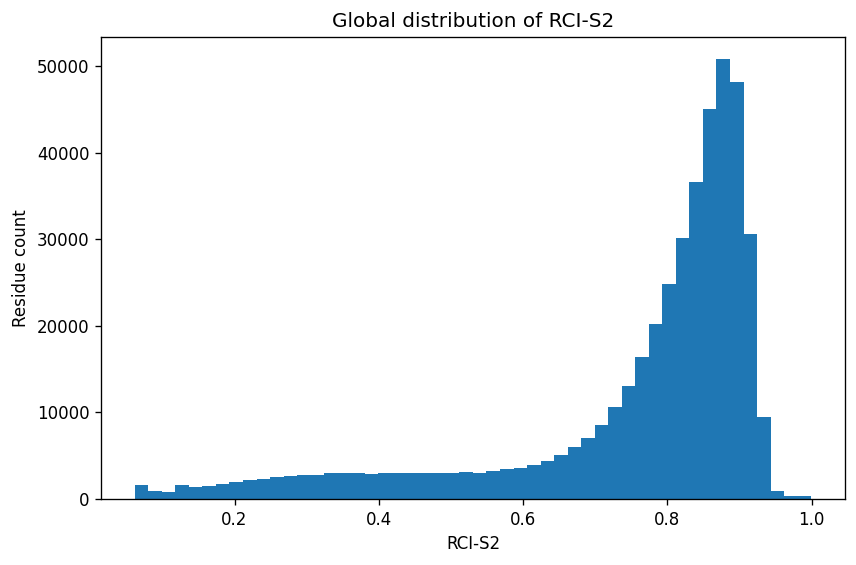

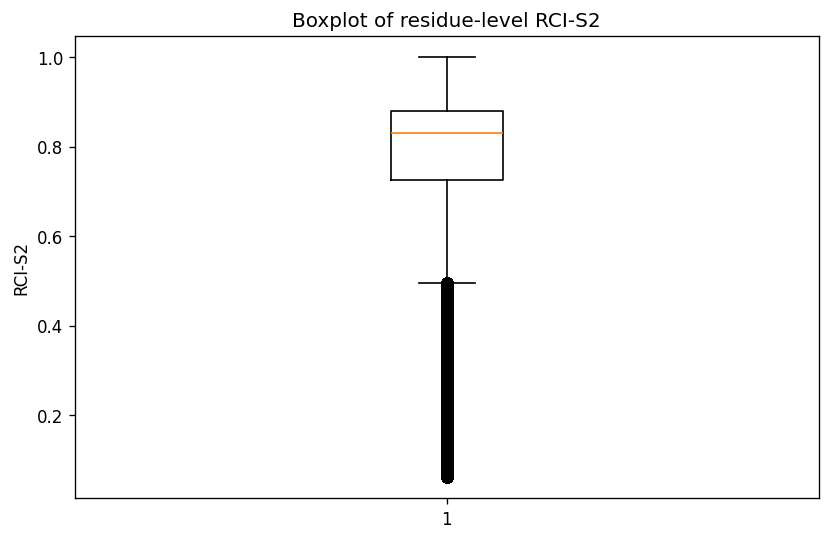

In [10]:
fig, ax = plt.subplots()
ax.hist(residue_df[target_col].dropna(), bins=50)
ax.set_title('Global distribution of RCI-S2')
ax.set_xlabel('RCI-S2')
ax.set_ylabel('Residue count')
plt.show()

fig, ax = plt.subplots()
ax.boxplot(residue_df[target_col].dropna(), vert=True)
ax.set_title('Boxplot of residue-level RCI-S2')
ax.set_ylabel('RCI-S2')
plt.show()

### interpretation

The residue-level dataset contains **444,304 residues** from **4,089 proteins**.  
The global RCI-S2 distribution is **skewed toward higher RCI-S2 values, so ordered / less mobile residues are more common than highly flexible ones**.

Key descriptive statistics:
- mean = **0.757**
- median = **0.831**
- standard deviation = **0.190**
- interquartile range = **[0.726, 0.879]**

Overall, this indicates a **broad target distribution**. For modeling, this means the task is not degenerate, but a baseline model may still benefit from predicting values toward the dominant region of the distribution.


--------------------------------------------------------------------------------

### Interpretation notes for the global target distribution

Use the histogram and summary table together to answer:

- Is the dataset skewed toward **high RCI-S2** (more ordered / less mobile backbone) or does it cover the full range evenly?
- Is there still a meaningful **low-RCI-S2 tail** that represents flexible regions?
- Is the spread broad enough to justify a regression task?

In this thesis, the key point is not only the mean value but whether the dataset contains enough variation to learn biologically meaningful differences in local backbone behavior.


## 2. Protein-level heterogeneity

This checks how much variability exists **within** and **between** proteins.

In [13]:
protein_stats = (
    residue_df
    .groupby(protein_col)[target_col]
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .rename(columns={'count': 'n_residues'})
    .reset_index()
)
protein_stats['range'] = protein_stats['max'] - protein_stats['min']
protein_stats = protein_stats.sort_values('mean')

print('Protein-level target summary:')
display(protein_stats[['n_residues', 'mean', 'std', 'range']].describe())

print('Proteins with lowest mean RCI-S2:')
display(protein_stats[[protein_col, 'n_residues', 'mean', 'std', 'range']].head(10))

print('Proteins with highest mean RCI-S2:')
display(protein_stats[[protein_col, 'n_residues', 'mean', 'std', 'range']].tail(10))

Protein-level target summary:


,n_residues,mean,std,range
count,4089.000000,4089.000000,4089.000000,4089.000000
mean,108.658352,0.754125,0.154440,0.656402
std,39.438338,0.098251,0.059832,0.189583
min,31.000000,0.216148,0.003576,0.017000
25%,81.000000,0.732115,0.105919,0.525300
50%,105.000000,0.779320,0.152377,0.701500
75%,129.000000,0.812889,0.199702,0.820200
max,442.000000,0.987311,0.332823,0.911500


Proteins with lowest mean RCI-S2:


,protein_id,n_residues,mean,std,range
1854,entry_01867,46,0.216148,0.091261,0.3602
3218,entry_03245,57,0.236918,0.109936,0.5258
3189,entry_03215,98,0.259720,0.104488,0.6035
3130,entry_03155,116,0.264349,0.097709,0.5775
3974,entry_04011,76,0.279891,0.094311,0.4568
3921,entry_03957,118,0.284286,0.106350,0.5349
4038,entry_04076,107,0.284434,0.086920,0.3883
2959,entry_02983,135,0.285887,0.108018,0.5322
3117,entry_03142,387,0.291800,0.112965,0.7057
3949,entry_03986,42,0.296329,0.109877,0.4529


Proteins with highest mean RCI-S2:


,protein_id,n_residues,mean,std,range
3534,entry_03567,146,0.906769,0.118212,0.7872
3132,entry_03157,78,0.910841,0.032802,0.1289
1118,entry_01130,99,0.919361,0.031123,0.1568
2483,entry_02502,155,0.928771,0.121337,0.9115
839,entry_00849,130,0.943631,0.029503,0.2298
1661,entry_01673,62,0.974602,0.054797,0.3518
1662,entry_01674,62,0.974602,0.054797,0.3518
3530,entry_03563,156,0.975346,0.011593,0.0539
3077,entry_03102,156,0.975346,0.011593,0.0539
2574,entry_02593,47,0.987311,0.003576,0.0170


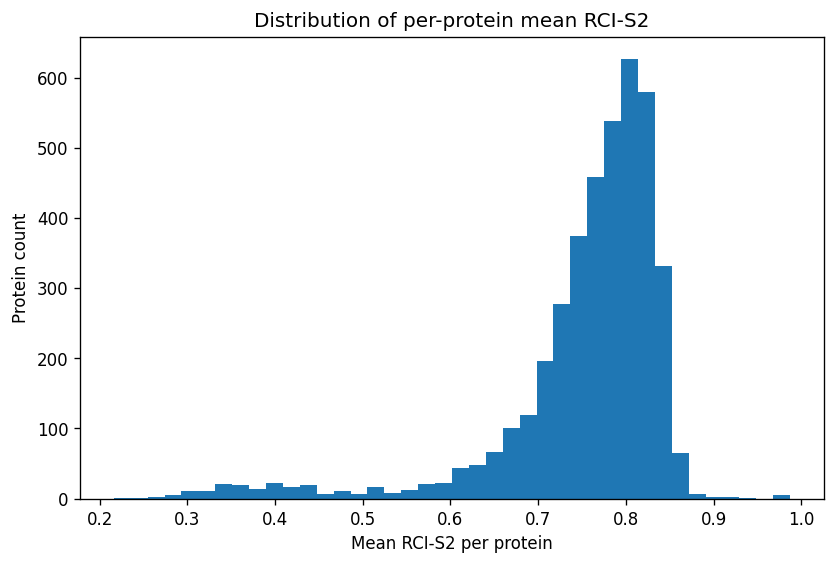

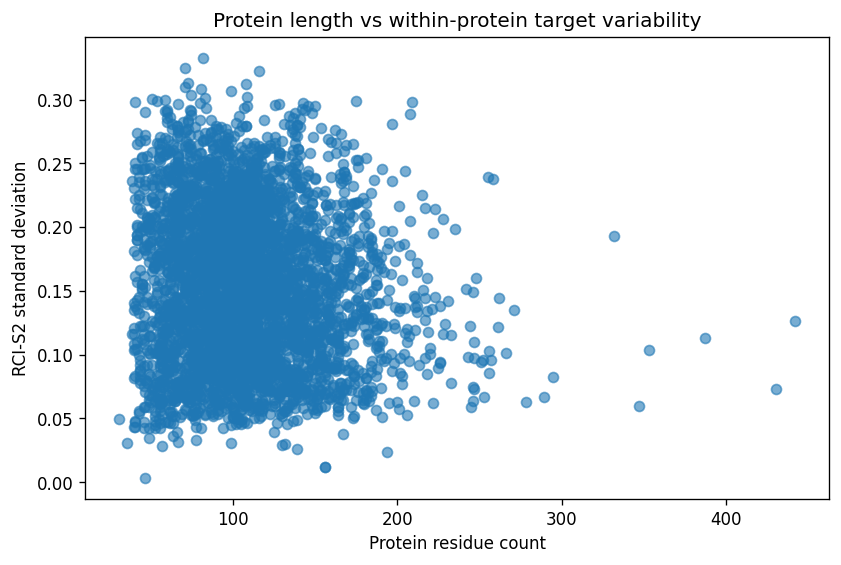

In [14]:
fig, ax = plt.subplots()
ax.hist(protein_stats['mean'].dropna(), bins=40)
ax.set_title('Distribution of per-protein mean RCI-S2')
ax.set_xlabel('Mean RCI-S2 per protein')
ax.set_ylabel('Protein count')
plt.show()

fig, ax = plt.subplots()
ax.scatter(protein_stats['n_residues'], protein_stats['std'], alpha=0.6)
ax.set_title('Protein length vs within-protein target variability')
ax.set_xlabel('Protein residue count')
ax.set_ylabel('RCI-S2 standard deviation')
plt.show()

### interpretation

Protein-level statistics show **very strong between-protein heterogeneity** in mean RCI-S2, with per-protein means ranging from **0.216 to 0.987**.

Within proteins, the average standard deviation is **0.154** and the average within-protein range is **0.656**, indicating **substantial internal variation** along many sequences.

This suggests the dataset contains both:

- proteins that are globally more ordered or more flexible, and
- proteins with mixed rigid and flexible segments inside the same chain.

This is a strong argument for **protein-level train/validation/test splits**.


### Why this matters for ML

If proteins differ strongly in their mean or variance, you should preserve this heterogeneity across **protein-level train/validation/test splits**. Otherwise, residue-level leakage could inflate performance.

This section also tells you whether the target variation is mostly:
- **between proteins** (some proteins globally more ordered/flexible), or
- **within proteins** (mixed rigid and flexible regions inside the same chain).

That distinction will matter when interpreting downstream model performance.

-------------------


## 3. Amino-acid level effects

This tests whether some residue identities are associated with systematically lower or higher RCI-S2 values.

,amino_acid,count,mean,std,median
0,G,32180,0.673449,0.222853,0.7625
1,P,19254,0.689406,0.191360,0.7588
2,S,29754,0.691755,0.232821,0.7945
3,H,9443,0.728988,0.225040,0.8240
4,M,9442,0.734798,0.212640,0.8242
5,N,18652,0.736005,0.188554,0.8052
6,A,32914,0.748347,0.197891,0.8309
7,Q,19309,0.750498,0.196532,0.8318
8,K,31987,0.758165,0.186562,0.8310
9,E,35141,0.761691,0.186609,0.8390


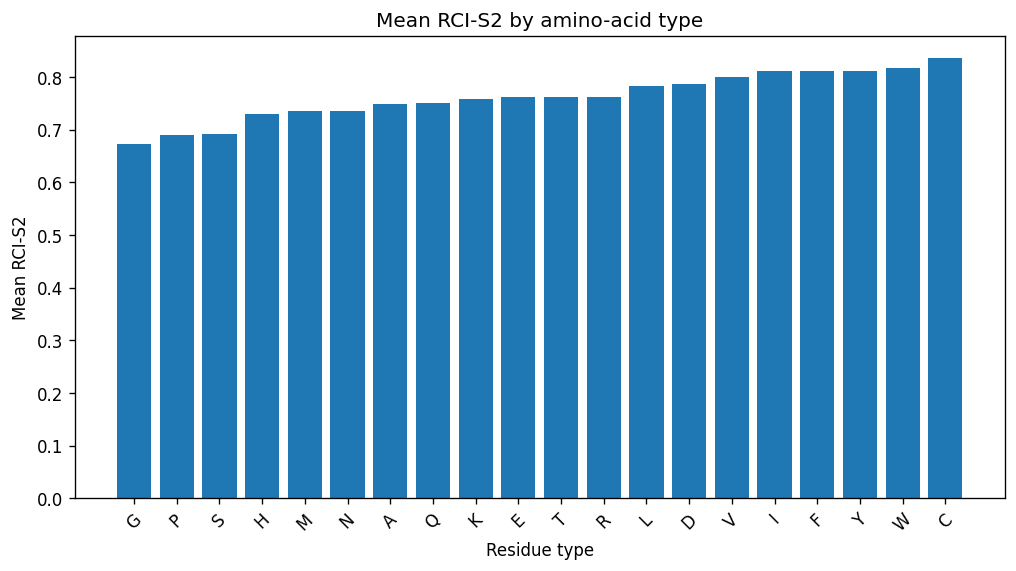

In [16]:
if aa_col is None:
    print('No residue identity column was detected. Skip this section or rename the amino-acid column.')
else:
    aa_stats = (
        residue_df
        .groupby(aa_col)[target_col]
        .agg(['count', 'mean', 'std', 'median'])
        .sort_values('mean')
        .reset_index()
    )
    display(aa_stats)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(aa_stats[aa_col].astype(str), aa_stats['mean'])
    ax.set_title('Mean RCI-S2 by amino-acid type')
    ax.set_xlabel('Residue type')
    ax.set_ylabel('Mean RCI-S2')
    plt.xticks(rotation=45)
    plt.show()

### Interpretation

Residue identity already carries visible signal for the target.

Lowest mean RCI-S2 residue types:
- G (**0.673**), P (**0.689**), S (**0.692**)

Highest mean RCI-S2 residue types:
- C (**0.835**), W (**0.818**), Y (**0.812**)

This means the target is not behaving like random noise. Part of the variation is already aligned with residue chemistry and structural propensity, which supports the idea that **sequence-derived embeddings should contain useful predictive information**.

### Notes for amino-acid level effects

Strong residue-type effects mean that part of the target is already related to **basic biochemical preferences**.

Typical patterns that are biologically plausible:
- **glycine / proline / serine** tending lower, often associated with more flexible or turn-like contexts
- **hydrophobic / aromatic residues** tending higher, often associated with more packed and ordered environments

This does **not** make the task trivial, but it supports the idea that sequence-derived embeddings should contain useful signal for RCI-S2.

-----------


## 4. Positional effects within proteins

This asks whether termini tend to be more flexible than central regions.

,position_bin,count,mean,std
0,"(-0.001, 0.1]",46247,0.630080,0.256666
1,"(0.1, 0.2]",44286,0.770882,0.172161
2,"(0.2, 0.3]",43786,0.790241,0.152777
3,"(0.3, 0.4]",44244,0.796310,0.142625
4,"(0.4, 0.5]",44587,0.793875,0.143858
5,"(0.5, 0.6]",43468,0.794958,0.143482
6,"(0.6, 0.7]",43768,0.799918,0.139176
7,"(0.7, 0.8]",44262,0.795809,0.145583
8,"(0.8, 0.9]",43810,0.780364,0.164883
9,"(0.9, 1.0]",45846,0.628963,0.255286


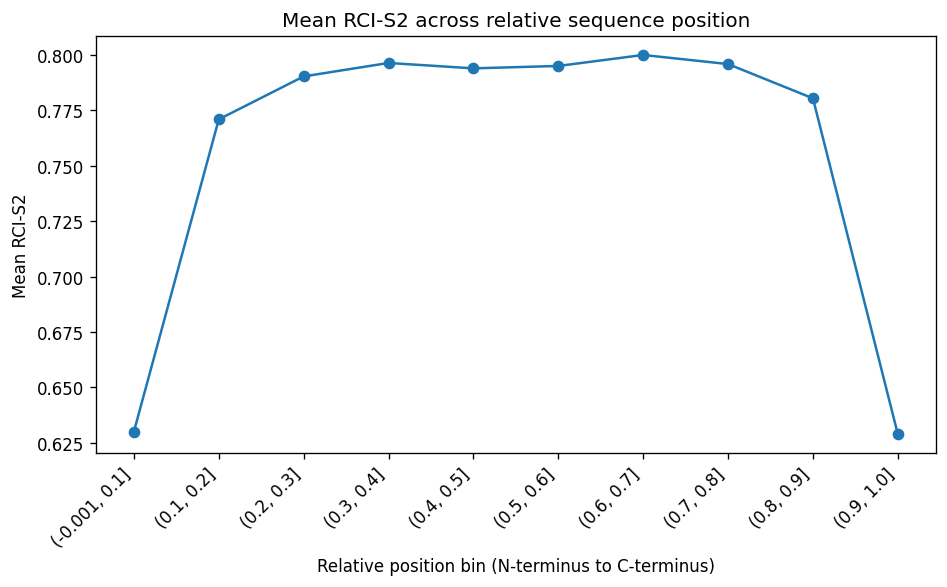

In [18]:
residue_pos_df = add_relative_position(residue_df, protein_col, residue_idx_col)
position_bins = np.linspace(0, 1, 11)
residue_pos_df['position_bin'] = pd.cut(residue_pos_df['relative_position'], bins=position_bins, include_lowest=True)
position_summary = residue_pos_df.groupby('position_bin')[target_col].agg(['count', 'mean', 'std']).reset_index()
display(position_summary)

fig, ax = plt.subplots()
ax.plot(range(len(position_summary)), position_summary['mean'], marker='o')
ax.set_title('Mean RCI-S2 across relative sequence position')
ax.set_xlabel('Relative position bin (N-terminus to C-terminus)')
ax.set_ylabel('Mean RCI-S2')
ax.set_xticks(range(len(position_summary)))
ax.set_xticklabels([str(x) for x in position_summary['position_bin']], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### interpretation

Both termini are substantially more flexible (lower RCI-S2) than the middle of the sequence.

Numerically:
- first position bin mean = **0.630**
- middle position bin mean = **0.795**
- last position bin mean = **0.629**

This pattern is biologically plausible because terminal regions are often less constrained than the protein interior. It also suggests that residue-level prediction may benefit from **context beyond a single residue embedding**.

-----------

## 6. Sequence smoothness and local autocorrelation

RCI-S2 is expected to vary smoothly along sequence in many proteins. This section quantifies local dependence.

,lag,mean_autocorr,n_proteins
0,1,0.929434,4089
1,2,0.762940,4089
2,3,0.558555,4089
3,4,0.386605,4089
4,5,0.257380,4089
5,6,0.165629,4089
6,7,0.100415,4089
7,8,0.057380,4089
8,9,0.031380,4089
9,10,0.016310,4089


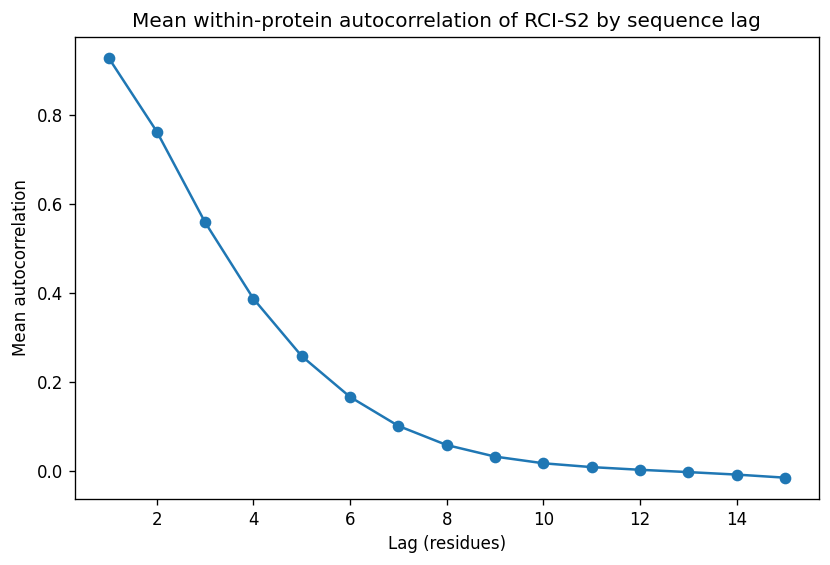

In [22]:
autocorr_df = lag_autocorr_by_protein(residue_df, protein_col, residue_idx_col, target_col, max_lag=15)
display(autocorr_df)

fig, ax = plt.subplots()
ax.plot(autocorr_df['lag'], autocorr_df['mean_autocorr'], marker='o')
ax.set_title('Mean within-protein autocorrelation of RCI-S2 by sequence lag')
ax.set_xlabel('Lag (residues)')
ax.set_ylabel('Mean autocorrelation')
plt.show()

In [23]:
# Example segmentation into low / medium / high order using quantiles.
q_low = residue_df[target_col].quantile(0.25)
q_high = residue_df[target_col].quantile(0.75)

run_summary = []
for pid, g in residue_df.sort_values([protein_col, residue_idx_col]).groupby(protein_col):
    y = g[target_col].to_numpy()
    low_runs = contiguous_run_lengths(y <= q_low)
    high_runs = contiguous_run_lengths(y >= q_high)
    run_summary.append({
        protein_col: pid,
        'n_low_runs': len(low_runs),
        'mean_low_run_length': np.nan if not low_runs else float(np.mean(low_runs)),
        'n_high_runs': len(high_runs),
        'mean_high_run_length': np.nan if not high_runs else float(np.mean(high_runs)),
    })
run_summary_df = pd.DataFrame(run_summary)
display(run_summary_df.describe())

,n_low_runs,mean_low_run_length,n_high_runs,mean_high_run_length
count,4089.000000,4051.000000,4089.000000,3868.000000
mean,4.046711,9.015874,6.089998,4.686149
std,1.919877,19.189516,3.261397,4.828635
min,0.000000,1.000000,0.000000,1.000000
25%,3.000000,3.666667,4.000000,3.444444
50%,4.000000,5.000000,6.000000,4.250000
75%,5.000000,7.500000,8.000000,5.166667
max,32.000000,442.000000,24.000000,156.000000


### Generated interpretation

The target shows **very strong local smoothness** along sequence.

Autocorrelation summary:
- lag 1 = **0.929**
- lag 3 = **0.559**
- lag 5 = **0.257**

This means neighboring residues often share similar local backbone behavior, so RCI-S2 is organized in **contiguous segments**, not isolated residue spikes.

Run-based summary (quantile thresholds):
- mean number of low-RCI-S2 runs per protein = **4.05**
- mean low-run length = **9.02**
- mean number of high-RCI-S2 runs per protein = **6.09**
- mean high-run length = **4.69**

This is a direct argument for trying **window-based or sequence-aware neural models** after the simple baselines.

### Why this matters for ML

A high short-range autocorrelation means the problem contains **local continuity**. Models can therefore succeed partly by learning contextual smoothing, not only by memorizing residue identities.

This is the clearest justification for trying:
- sliding-window baselines
- 1D CNNs
- or other neighborhood-aware models

At the same time, this means you should avoid overclaiming that all performance comes from deep biophysical understanding; some of it may come from the segmental smoothness of the target.
